# Display final assignment — battery results

Notebook leggero per visualizzare **solo l'assegnamento finale** prodotto dal
binario Rust `nshift`, a partire dai risultati di una batteria di test generata
da `run_battery.py`.

Esegui le celle in ordine: la prima cella dopo gli import elenca i run
disponibili sotto `results/` e permette di sceglierne uno tramite indice
(`RUN_INDEX`) invece di scrivere a mano il path.

Presuppone backend **rust** (cerca `summary_by_n.csv` e `N<k>/per_request.csv`
dentro la cartella scelta, come scritti dal binario `nshift`).

In [8]:
%matplotlib inline
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

# --- user options (RUN_DIR / SELECTED_N are chosen in the picker cell below) ---
# Final assignment highlight plot mode: "scatter" | "stacked" | "both"
TIMELINE_HIGHLIGHT_PLOT_MODE = "both"

# Group size, in slots, for the aggregate carbon-cost labels on stacked plots.
CARBON_COST_GROUP_SIZE = 12


In [9]:
# Locate the carbonshift package root (the directory containing `online2/`)
# by walking up from the notebook's working directory — the same root that
# run_battery.py calls CARBONSHIFT_ROOT. This notebook lives in
# `tests/battery/`, a sibling of `online2/`, rather than inside
# `online2/notebooks/` like the original analysis notebook, so we search
# upward instead of assuming a fixed number of parent levels.

def _find_carbonshift_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "rust").exists():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the carbonshift root (a directory containing "
        f"'online2/tests/Nshift_speed') starting from {start}. Run this "
        "notebook from within the carbonshift repo (e.g. tests/battery/), "
        "or set CARBONSHIFT_ROOT manually below."
    )

CARBONSHIFT_ROOT = _find_carbonshift_root(Path.cwd().resolve())

# Reuse the same flavour colors / dataframe-prep helpers as
# nshift_assignment_analysis.ipynb, so the final-assignment plots match it
# in style.
from nb_utils import (
    FLAVOUR_COLORS,
    bool_series as _bool_series,
    resolve_plot_mode as _resolve_plot_mode,
    prepare_local as _prepare_timeline,
    flavour_order as _flavour_order,
)

print(f"CARBONSHIFT_ROOT = {CARBONSHIFT_ROOT}")

CARBONSHIFT_ROOT = /home/francis/unipi/carbonshift/carbonshift


In [10]:
# ── Pick which run to visualize ───────────────────────────────────────────
# Scans results/ (recursively) for "rust_<mode>" directories that contain
# per-N results (summary_by_n.csv / N<k>/per_request.csv), covering both the
# new per-run folders written by run_battery.py (results/<battery_id>_.../
# <scenario_id>/rust_<mode>/) and the legacy flat layout
# (results/<scenario_id>/rust_<mode>/).

RESULTS_ROOT = CARBONSHIFT_ROOT / "tests" / "battery" / "results"

def _available_n(mode_dir: Path) -> list:
    return sorted(int(p.name[1:]) for p in mode_dir.glob("N*") if p.name[1:].isdigit())

def _find_mode_dirs(root: Path) -> list:
    # dirs = [d for d in root.glob("**/rust_*") if d.is_dir() and _available_n(d)]
    dirs = [d for d in root.glob("cfg_onlyhigh_dp_3_0726_2204_8_roll0_0_F_M/high_load_1500_92/rust_*") if d.is_dir() and _available_n(d)]
    
    return sorted(dirs, key=lambda d: d.stat().st_mtime, reverse=True)

_available_runs = _find_mode_dirs(RESULTS_ROOT)
print(f"Found {len(_available_runs)} run(s) under {RESULTS_ROOT}:")
for i, d in enumerate(_available_runs):
    print(f"  [{i}] {d.relative_to(RESULTS_ROOT)}  N={_available_n(d)}")

# Index (from the list above) of the run to visualize.
RUN_INDEX = 0

# batch_size (N) to visualize. Leave as None to use the largest available N.
SELECTED_N = None

RUN_DIR = _available_runs[RUN_INDEX]
if SELECTED_N is None:
    SELECTED_N = _available_n(RUN_DIR)[-1]

print(f"\nSelected: {RUN_DIR.relative_to(RESULTS_ROOT)}  N={SELECTED_N}")


Found 1 run(s) under /home/francis/unipi/carbonshift/carbonshift/tests/battery/results:
  [0] cfg_onlyhigh_dp_3_0726_2204_8_roll0_0_F_M/high_load_1500_92/rust_min_error_greedy  N=[4]

Selected: cfg_onlyhigh_dp_3_0726_2204_8_roll0_0_F_M/high_load_1500_92/rust_min_error_greedy  N=4


In [11]:
# --- load data for the run selected by the picker cell above ---
run_dir = RUN_DIR
if not run_dir.exists():
    raise FileNotFoundError(f"Run directory not found: {run_dir}")

# `run_dir` is expected to look like .../results/<scenario_id>/rust_<mode>/
scenario_id = run_dir.parent.name
mode_dir_name = run_dir.name
mode_label = mode_dir_name[len("rust_"):] if mode_dir_name.startswith("rust_") else mode_dir_name

n_dir = run_dir / f"N{int(SELECTED_N)}"
per_request_path = n_dir / "per_request.csv"
if not per_request_path.exists():
    raise FileNotFoundError(
        f"Missing per_request.csv for N={SELECTED_N}: {per_request_path}\n"
        f"Available N folders in {run_dir}: {sorted(p.name for p in run_dir.glob('N*'))}"
    )

per_request = pd.read_csv(per_request_path)

summary_path = run_dir / "summary_by_n.csv"
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    summary_df["batch_size"] = pd.to_numeric(summary_df["batch_size"], errors="coerce")
    run_summary = summary_df[summary_df["batch_size"] == int(SELECTED_N)]
else:
    print(f"WARNING: {summary_path} not found; skipping summary display.")
    run_summary = pd.DataFrame()

# Scenarios generated by run_battery.py now live in a centralized folder,
# tests/battery/scenarios/json/<scenario_id>.json, rather than alongside each
# run's output directory. Fall back to the legacy per-run location (and a
# "scenario_seed_*" glob) for older result sets generated before this change.
SCENARIOS_JSON_DIR = CARBONSHIFT_ROOT / "tests" / "battery" / "scenarios" / "json"
preferred_scenario_path = SCENARIOS_JSON_DIR / f"{scenario_id}.json"
if preferred_scenario_path.exists():
    scenario_candidates = [preferred_scenario_path]
else:
    scenario_candidates = sorted(SCENARIOS_JSON_DIR.glob(f"*{scenario_id}*.json"))
if not scenario_candidates:
    # Legacy fallback: scenario copied next to the run's mode directories.
    scenario_suffix = scenario_id.split("_")[-1]
    legacy_preferred = run_dir.parent / f"scenario_seed_{scenario_suffix}.json"
    scenario_candidates = [legacy_preferred] if legacy_preferred.exists() else sorted(run_dir.parent.glob("scenario*.json"))
scenario_path = scenario_candidates[0] if scenario_candidates else None
if scenario_path is not None:
    scenario = json.loads(scenario_path.read_text(encoding="utf-8"))
else:
    print(f"WARNING: no scenario JSON found for '{scenario_id}' in {SCENARIOS_JSON_DIR} or {run_dir.parent}; carbon forecast and capacity tiers unavailable.")
    scenario = {}

scenario_meta = scenario.get("metadata", {})
carbon_forecast = [float(v) for v in scenario.get("carbon_forecast", [])]
capacity_tiers = list(scenario_meta.get("capacity_tiers", []))
total_slots = int(
    scenario_meta.get(
        "total_slots",
        max(int(pd.to_numeric(per_request["scheduled_slot"], errors="coerce").max()) + 1, len(carbon_forecast))
        if "scheduled_slot" in per_request.columns and not per_request.empty
        else len(carbon_forecast),
    )
)

print(f"Scenario: {scenario_id}   Mode: {mode_label}   N: {SELECTED_N}")
print(f"Loaded {len(per_request)} requests from {per_request_path}")
if scenario_path is not None:
    print(f"Loaded scenario from {scenario_path}")
if not run_summary.empty:
    display(run_summary.round(4))


Scenario: high_load_1500_92   Mode: min_error_greedy   N: 4
Loaded 70788 requests from /home/francis/unipi/carbonshift/carbonshift/tests/battery/results/cfg_onlyhigh_dp_3_0726_2204_8_roll0_0_F_M/high_load_1500_92/rust_min_error_greedy/N4/per_request.csv
Loaded scenario from /home/francis/unipi/carbonshift/carbonshift/tests/battery/scenarios/json/high_load_1500_92.json


,execution_mode,batch_size,realtime_slots,realtime_speed_scale,baseline_flavour_name,baseline_flavour_duration,baseline_flavour_error,requests_total,requests_scheduled,requests_unscheduled,requests_late,max_lateness_slots,batches_executed,carbon_cost,global_average_error,global_average_error_real,global_average_error_modeled,global_average_error_real_skip_first_k,global_average_error_modeled_skip_first_k,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,peak_consecutive_rollbacks,requests_assigned_with_rollback,peak_concurrent_workers,avg_concurrent_workers,solver_time_ms_min,solver_time_ms_max,solver_time_ms_avg,queue_wait_seconds_min,queue_wait_seconds_max,queue_wait_seconds_avg,final_wait_seconds_min,final_wait_seconds_max,final_wait_seconds_avg,baseline_carbon_cost,carbon_cost_saving_vs_baseline,carbon_saving,run_elapsed_seconds
0,nshift_dp,4,False,1,NaN,0,0,70788,70788,0,0,0,17714,32864.8568,4.4999,4.4999,4.4999,0,0,3,0,0,0,0,8,6.4292,0.1126,74.2074,10.131,0,0,0,0,80,27.1279,136842.6963,103977.8395,75.9835,52.8045


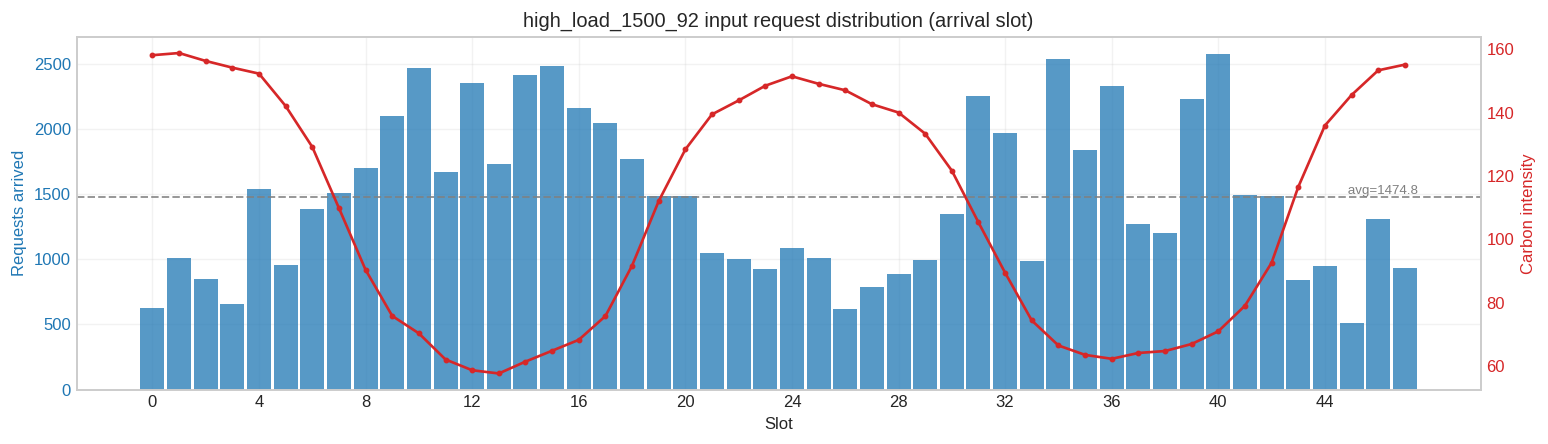

In [12]:
# --- input request distribution over timeslots ---
# Shows how many requests *arrived* in each slot (arrival_slot), i.e. the raw
# input load the scenario generator produced — independent of how the solver
# later scheduled/shifted them. Useful to sanity-check the load-vs-carbon
# wave shape before looking at assignment plots.
def _plot_request_distribution(requests, total_slots, title, carbon_forecast=None):
    if not requests:
        print("No requests found in the scenario; skipping request distribution plot.")
        return

    arrival_slots = pd.Series([int(r["arrival_slot"]) for r in requests])
    counts = arrival_slots.value_counts().reindex(range(total_slots), fill_value=0).sort_index()

    fig, ax = plt.subplots(figsize=(13, 3.8))
    ax.bar(counts.index, counts.to_numpy(), width=0.9, color="#1f77b4", alpha=0.75, label="Requests")
    ax.set_xlabel("Slot")
    ax.set_ylabel("Requests arrived", color="#1f77b4")
    ax.tick_params(axis="y", labelcolor="#1f77b4")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    tick_step = max(1, total_slots // 12)
    ax.set_xticks(list(range(0, total_slots, tick_step)))

    if carbon_forecast:
        ax2 = ax.twinx()
        ci = pd.Series(carbon_forecast, dtype=float)
        ax2.plot(ci.index, ci.to_numpy(), color="#d62728", linewidth=1.6, marker="o", markersize=2.5, label="Carbon intensity")
        ax2.set_ylabel("Carbon intensity", color="#d62728")
        ax2.tick_params(axis="y", labelcolor="#d62728")
        ax2.grid(False)

    avg = counts.mean()
    ax.axhline(avg, linestyle="--", linewidth=1.2, color="gray", alpha=0.8)
    ax.text(total_slots - 0.5, avg, f" avg={avg:.1f}", va="bottom", ha="right", fontsize=8, color="gray")

    plt.tight_layout()


_plot_request_distribution(
    scenario.get("requests", []),
    total_slots,
    title=f"{scenario_id} input request distribution (arrival slot)",
    carbon_forecast=carbon_forecast,
)


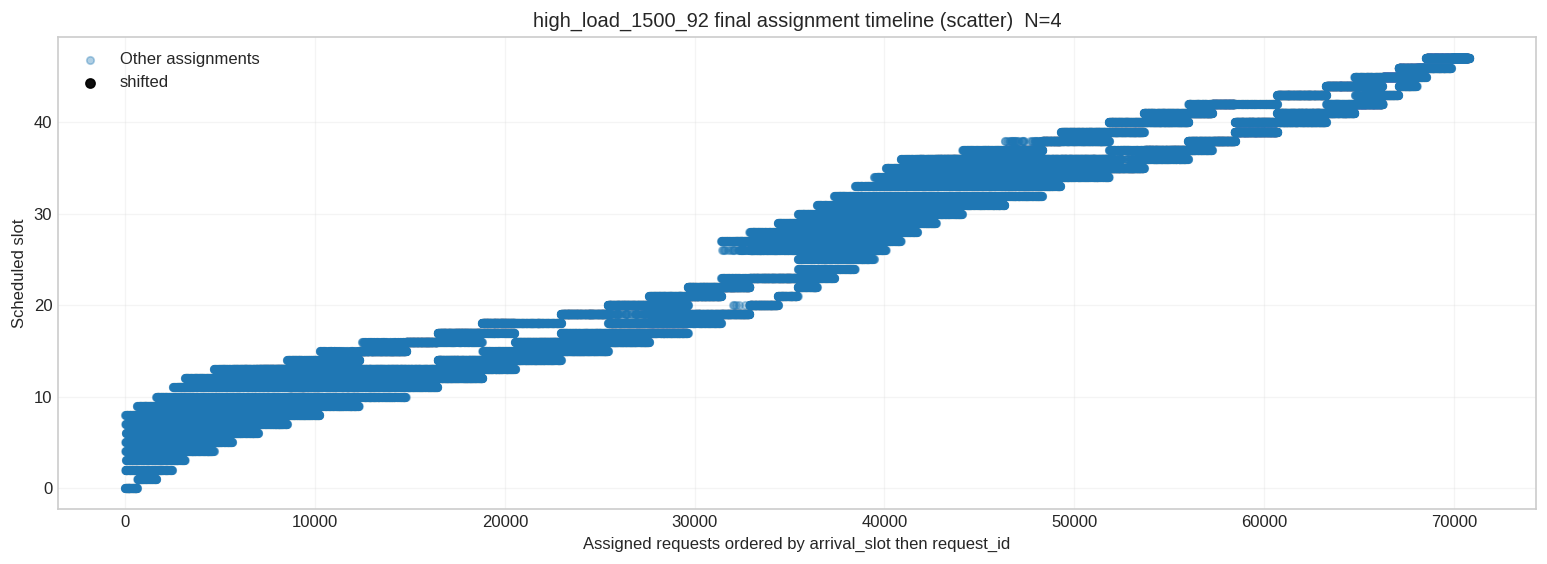

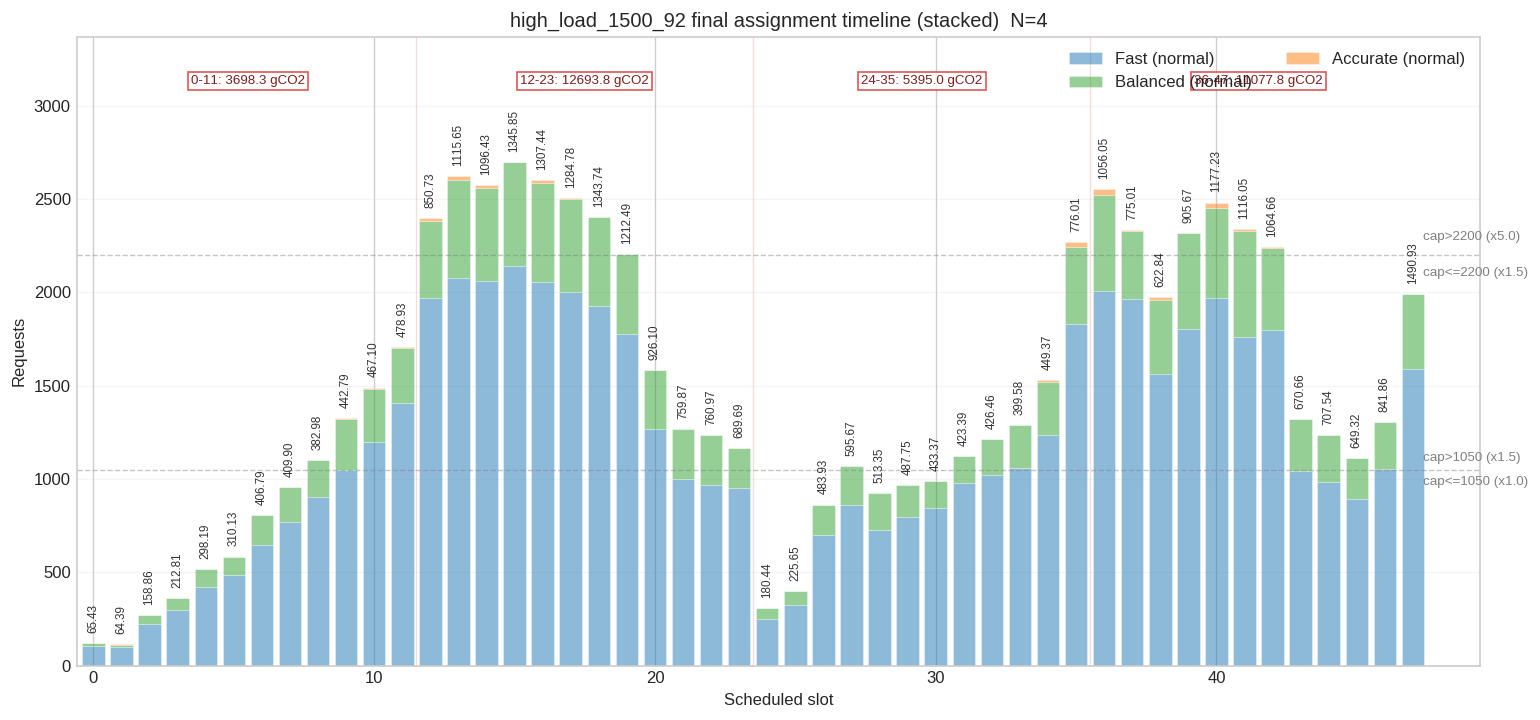

In [13]:
# Same plotting helpers as the "final timeline" cell of
# nshift_assignment_analysis.ipynb, with battery-scenario overlays.

def _format_number(value):
    value = float(value)
    return f"{value:g}"


def _capacity_tier_rows():
    rows = []
    for tier in capacity_tiers:
        max_req = tier.get("max_requests") if isinstance(tier, dict) else None
        if max_req is None or pd.isna(max_req):
            continue
        try:
            max_req = float(max_req)
        except (TypeError, ValueError):
            continue
        rows.append(
            {
                "max_requests": max_req,
                "multiplier": tier.get("multiplier", "?") if isinstance(tier, dict) else "?",
            }
        )
    return rows


def _slot_carbon_costs(local, slots):
    if "carbon_cost" not in local.columns:
        return None
    carbon = local.copy()
    carbon["carbon_cost"] = pd.to_numeric(carbon["carbon_cost"], errors="coerce").fillna(0.0)
    return carbon.groupby("scheduled_slot")["carbon_cost"].sum().reindex(slots, fill_value=0.0)


def _carbon_cost_group_rows(carbon_costs, group_size):
    if carbon_costs is None:
        return []
    try:
        group_size = int(group_size)
    except (TypeError, ValueError):
        return []
    if group_size <= 0 or carbon_costs.empty:
        return []

    max_slot = int(max(carbon_costs.index))
    rows = []
    for start in range(0, max_slot + 1, group_size):
        end = min(start + group_size - 1, max_slot)
        group_slots = list(range(start, end + 1))
        total = float(carbon_costs.reindex(group_slots, fill_value=0.0).sum())
        rows.append(
            {
                "start": start,
                "end": end,
                "center": (start + end) / 2,
                "total": total,
            }
        )
    return rows


def _plot_scatter_timeline(local, flag_mask, title, dark_label):
    fig, ax = plt.subplots(figsize=(13, 4.8))
    x = local.index.to_numpy()
    y = local["scheduled_slot"].to_numpy()
    flags = flag_mask.to_numpy()

    ax.scatter(x[~flags], y[~flags], s=20, alpha=0.35, color="tab:blue", label="Other assignments")
    ax.scatter(x[flags], y[flags], s=30, alpha=0.95, color="black", label=dark_label)

    ax.set_xlabel("Assigned requests ordered by arrival_slot then request_id")
    ax.set_ylabel("Scheduled slot")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(alpha=0.2)
    plt.tight_layout()


def _plot_stacked_timeline(local, flag_mask, title, dark_label):
    fig, ax = plt.subplots(figsize=(13, 6.1))
    slots = sorted(local["scheduled_slot"].unique().tolist())
    if not slots:
        ax.set_title(f"{title} (no assignments)")
        ax.grid(alpha=0.2)
        plt.tight_layout()
        return

    bottom = pd.Series(0, index=slots, dtype=float)
    strategies = _flavour_order(local)
    for flavour in strategies:
        base_color = FLAVOUR_COLORS.get(flavour, "#7f7f7f")

        flavour_mask = local["flavour_name"] == flavour
        normal_counts = (
            local[flavour_mask & (~flag_mask)]
            .groupby("scheduled_slot")
            .size()
            .reindex(slots, fill_value=0)
        )
        highlighted_counts = (
            local[flavour_mask & flag_mask]
            .groupby("scheduled_slot")
            .size()
            .reindex(slots, fill_value=0)
        )

        if int(normal_counts.sum()) > 0:
            ax.bar(
                slots,
                normal_counts.values,
                bottom=bottom.values,
                color=base_color,
                alpha=0.5,
                edgecolor="white",
                linewidth=0.4,
                label=f"{flavour} (normal)",
            )
            bottom = bottom + normal_counts

        if int(highlighted_counts.sum()) > 0:
            ax.bar(
                slots,
                highlighted_counts.values,
                bottom=bottom.values,
                color=base_color,
                alpha=1.0,
                edgecolor="black",
                linewidth=0.6,
                label=f"{flavour} ({dark_label})",
            )
            bottom = bottom + highlighted_counts

    tier_rows = _capacity_tier_rows()
    overflow_mult = next(
        (t.get("multiplier") for t in capacity_tiers if isinstance(t, dict) and t.get("max_requests") is None),
        None,
    )
    for tier in tier_rows:
        max_req = tier["max_requests"]
        ax.axhline(y=max_req, linestyle="--", linewidth=0.85, alpha=0.45, color="gray")
        label_gap = max(0.5, max_req * 0.03)
        ax.text(
            max(slots) + 0.35,
            max_req - label_gap,
            f"cap<={_format_number(max_req)} (x{tier['multiplier']})",
            fontsize=8,
            color="gray",
            va="top",
        )
        next_tier = next((t for t in tier_rows if t["max_requests"] > max_req), None)
        above_mult = next_tier["multiplier"] if next_tier else overflow_mult
        if above_mult is not None:
            ax.text(
                max(slots) + 0.35,
                max_req + label_gap,
                f"cap>{_format_number(max_req)} (x{above_mult})",
                fontsize=8,
                color="gray",
                va="bottom",
            )

    all_cost_slots = list(range(max(total_slots, max(slots) + 1)))
    carbon_costs = _slot_carbon_costs(local, slots)
    carbon_costs_for_groups = _slot_carbon_costs(local, all_cost_slots)
    carbon_group_rows = _carbon_cost_group_rows(carbon_costs_for_groups, CARBON_COST_GROUP_SIZE)

    max_bar_height = float(bottom.max()) if len(bottom) else 0.0
    max_tier_height = max([tier["max_requests"] for tier in tier_rows], default=0.0)
    plot_top = max(max_bar_height, max_tier_height, 1.0)
    label_offset = max(0.35, plot_top * 0.02)
    group_label_y = plot_top + max(1.2, plot_top * 0.16)

    if carbon_costs is not None:
        for slot, value in carbon_costs.items():
            ax.text(
                slot,
                float(bottom.loc[slot]) + label_offset,
                f"{float(value):.2f}",
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=7,
                color="#333333",
                clip_on=False,
            )

    if carbon_group_rows:
        for row in carbon_group_rows:
            if row["start"] > min(slots):
                ax.axvline(row["start"] - 0.5, color="#d62728", alpha=0.16, linewidth=0.8)
            ax.text(
                row["center"],
                group_label_y,
                f"{row['start']}-{row['end']}: {row['total']:.1f} gCO2",
                ha="center",
                va="center",
                fontsize=8,
                color="#7f1d1d",
                bbox={"facecolor": "white", "edgecolor": "#d62728", "alpha": 0.78, "pad": 2.0},
                clip_on=False,
            )

    ax.set_xlabel("Scheduled slot")
    ax.set_ylabel("Requests")
    ax.set_title(title)
    ax.legend(loc="best", ncol=2)
    ax.grid(alpha=0.2, axis="y")
    y_limit_top = max(group_label_y + max(1.0, plot_top * 0.08), plot_top + max(2.0, plot_top * 0.24)) +20
    # set y to display values up to 420...
    #  The max number of requests in the data is about 180, but let's display as if it was 380
    
    # ax.set_ylim(0, 420)
    ax.set_ylim(0, y_limit_top)
    ax.set_xlim(min(slots) - 0.6, max(slots) + (2.4 if tier_rows else 0.6))
    plt.tight_layout()


def _plot_timeline(local, flag_col, title_scatter, title_stacked, dark_label):
    default_flags = pd.Series([False] * len(local), index=local.index)
    flags = _bool_series(local[flag_col]) if flag_col in local.columns else default_flags

    mode = _resolve_plot_mode(TIMELINE_HIGHLIGHT_PLOT_MODE)
    if mode in {"scatter", "both"}:
        _plot_scatter_timeline(local, flags, title_scatter, dark_label)
    if mode in {"stacked", "both"}:
        _plot_stacked_timeline(local, flags, title_stacked, dark_label)


# plot the final assignment timeline
_plot_timeline(
    local=_prepare_timeline(per_request),
    flag_col="is_shifted",
    title_scatter=f"{scenario_id} final assignment timeline (scatter)  N={SELECTED_N}",
    title_stacked=f"{scenario_id} final assignment timeline (stacked)  N={SELECTED_N}",
    dark_label="shifted",
)


In [14]:
# Create a dataframe representing the final state of assignments per timeslot
# Rows: TimeSlot, Columns: flavour counts, carbon cost, average error

def create_final_state_dataframe(local_data):
    """
    Create a dataframe with one row per timeslot containing:
    - Count of requests assigned with each flavour
    - Total carbon cost
    - Average error for that timeslot
    """
    # Get the local data prepared for timeline
    df = _prepare_timeline(local_data)
    
    # Get all unique flavours in the data
    flavours = _flavour_order(df)
    
    # Get all timeslots
    slots = sorted(df["scheduled_slot"].unique().tolist())
    
    # Initialize the result dataframe
    result_data = []
    
    for slot in slots:
        # Filter data for this slot
        slot_data = df[df["scheduled_slot"] == slot]
        
        # Count requests by flavour
        flavour_counts = {}
        for flavour in flavours:
            count = len(slot_data[slot_data["flavour_name"] == flavour])
            flavour_counts[f"flavour_{flavour}"] = count
        
        # Calculate total carbon cost for this slot
        total_carbon = 0.0
        if "carbon_cost" in slot_data.columns:
            total_carbon = pd.to_numeric(slot_data["carbon_cost"], errors="coerce").sum()
        
        # Calculate average error for this slot
        avg_error = 0.0
        if "error" in slot_data.columns:
            error_values = pd.to_numeric(slot_data["error"], errors="coerce")
            avg_error = error_values.mean() if len(error_values) > 0 else 0.0
        
        # Combine all data
        row = {
            "TimeSlot": slot,
            **flavour_counts,
            "Total_Carbon_Cost": total_carbon,
            "Avg_Error": avg_error,
            "Total_Requests": len(slot_data)
        }
        result_data.append(row)
    
    # Create dataframe
    result_df = pd.DataFrame(result_data)
    
    # Sort by timeslot
    result_df = result_df.sort_values("TimeSlot").reset_index(drop=True)
    
    return result_df

# Create the final state dataframe
final_state_df = create_final_state_dataframe(per_request)

# Display the dataframe with formatted numbers
pd.set_option('display.float_format', '{:.2f}'.format)
print(f"Final State of Assignments by TimeSlot (N={SELECTED_N}, Scenario: {scenario_id})")
print("=" * 80)
display(final_state_df)

# Also show some summary statistics
print("\nSummary Statistics:")
print("-" * 40)
print(f"Total TimeSlots: {len(final_state_df)}")
print(f"Total Requests Assigned: {final_state_df['Total_Requests'].sum()}")
print(f"Total Carbon Cost: {final_state_df['Total_Carbon_Cost'].sum():.2f}")
print(f"Average Error (over all requests): {final_state_df['Avg_Error'].mean():.4f}")
print(f"Max Carbon Cost in a single slot: {final_state_df['Total_Carbon_Cost'].max():.2f}")
print(f"Min Carbon Cost in a single slot: {final_state_df['Total_Carbon_Cost'].min():.2f}")

# Show which flavours are present and their total counts
print("\nFlavour Distribution (Total Requests):")
print("-" * 40)
flavour_columns = [col for col in final_state_df.columns if col.startswith('flavour_')]
for col in flavour_columns:
    flavour_name = col.replace('flavour_', '')
    total = final_state_df[col].sum()
    print(f"{flavour_name}: {total} requests")

# Optional: Show the first few rows to see the structure
print("\nFirst 5 rows of the final state dataframe:")
display(final_state_df.head())

Final State of Assignments by TimeSlot (N=4, Scenario: high_load_1500_92)


,TimeSlot,flavour_Fast,flavour_Balanced,flavour_Accurate,Total_Carbon_Cost,Avg_Error,Total_Requests
0,0,104,15,0,65.43,4.68,119
1,1,98,14,1,64.39,4.65,113
2,2,222,48,0,158.86,4.56,270
3,3,296,67,0,212.81,4.54,363
4,4,423,94,0,298.19,4.55,517
5,5,483,101,0,310.13,4.57,584
6,6,645,161,1,406.79,4.50,807
7,7,770,187,2,409.90,4.50,959
8,8,905,197,0,382.98,4.55,1102
9,9,1046,274,7,442.79,4.46,1327



Summary Statistics:
----------------------------------------
Total TimeSlots: 48
Total Requests Assigned: 70788
Total Carbon Cost: 32864.86
Average Error (over all requests): 4.5171
Max Carbon Cost in a single slot: 1490.93
Min Carbon Cost in a single slot: 64.39

Flavour Distribution (Total Requests):
----------------------------------------
Fast: 56851 requests
Balanced: 13713 requests
Accurate: 224 requests

First 5 rows of the final state dataframe:


,TimeSlot,flavour_Fast,flavour_Balanced,flavour_Accurate,Total_Carbon_Cost,Avg_Error,Total_Requests
0,0,104,15,0,65.43,4.68,119
1,1,98,14,1,64.39,4.65,113
2,2,222,48,0,158.86,4.56,270
3,3,296,67,0,212.81,4.54,363
4,4,423,94,0,298.19,4.55,517


In [15]:
# Print min/avg/max of total requests assigned per timeslot (excluding the last timeslot)

# Get the final state dataframe
final_state_df = create_final_state_dataframe(per_request)

# Exclude the last timeslot from the calculation
df_excluding_last = final_state_df.iloc[:-1]  # Remove the last row (last timeslot)

# Calculate statistics on total requests per timeslot
total_requests_per_slot = df_excluding_last["Total_Requests"]

min_requests = total_requests_per_slot.min()
avg_requests = total_requests_per_slot.mean()
max_requests = total_requests_per_slot.max()

print(f"Statistics for Total Requests per TimeSlot (N={SELECTED_N}, Scenario: {scenario_id})")
print("=" * 60)
print(f"Excluding the last timeslot (timeslot {final_state_df.iloc[-1]['TimeSlot']})")
print("-" * 60)
print(f"Minimum requests in a timeslot: {min_requests:.0f}")
print(f"Average requests in a timeslot: {avg_requests:.2f}")
print(f"Maximum requests in a timeslot: {max_requests:.0f}")
print(f"Standard deviation: {total_requests_per_slot.std():.2f}")
print(f"Number of timeslots considered: {len(df_excluding_last)}")

# Also show which timeslots have min and max
print("\nDetails:")
print("-" * 60)
min_slots = df_excluding_last[df_excluding_last["Total_Requests"] == min_requests]["TimeSlot"].tolist()
max_slots = df_excluding_last[df_excluding_last["Total_Requests"] == max_requests]["TimeSlot"].tolist()

print(f"Timeslot(s) with minimum requests ({min_requests:.0f}): {min_slots}")
print(f"Timeslot(s) with maximum requests ({max_requests:.0f}): {max_slots}")

# Optional: Show a quick distribution
print("\nDistribution of requests per timeslot:")
print("-" * 60)
print(f"25th percentile: {total_requests_per_slot.quantile(0.25):.0f}")
print(f"Median (50th percentile): {total_requests_per_slot.median():.0f}")
print(f"75th percentile: {total_requests_per_slot.quantile(0.75):.0f}")

Statistics for Total Requests per TimeSlot (N=4, Scenario: high_load_1500_92)
Excluding the last timeslot (timeslot 47.0)
------------------------------------------------------------
Minimum requests in a timeslot: 113
Average requests in a timeslot: 1463.72
Maximum requests in a timeslot: 2701
Standard deviation: 780.29
Number of timeslots considered: 47

Details:
------------------------------------------------------------
Timeslot(s) with minimum requests (113): [1]
Timeslot(s) with maximum requests (2701): [15]

Distribution of requests per timeslot:
------------------------------------------------------------
25th percentile: 964
Median (50th percentile): 1291
75th percentile: 2294


In [16]:
# Analyze request timing patterns: late requests vs pending at end

def analyze_request_timing(per_request_data, last_slots_to_consider=10):
    """
    Analyze request timing to distinguish between:
    - Late requests: scheduled_slot > deadline_slot (or scheduled_slot == last_slot but arrival_slot much earlier)
    - Pending at end: arrival_slot high and scheduled_slot == last_slot
    - Compare distribution of arrival_slot vs scheduled_slot for last ~N time units
    """
    
    # Prepare the data
    df = _prepare_timeline(per_request_data)
    
    # Get the last timeslot
    last_slot = df["scheduled_slot"].max()
    
    # Get the last N slots to analyze
    all_slots = sorted(df["scheduled_slot"].unique())
    last_n_slots = all_slots[-last_slots_to_consider:] if len(all_slots) >= last_slots_to_consider else all_slots
    
    print(f"Analysis of Request Timing Patterns (N={SELECTED_N}, Scenario: {scenario_id})")
    print("=" * 80)
    print(f"Total requests: {len(df)}")
    print(f"Last timeslot: {last_slot}")
    print(f"Analyzing last {len(last_n_slots)} timeslots: {last_n_slots}")
    print("-" * 80)
    
    # 1. Identify late requests (scheduled_slot > deadline_slot)
    if "deadline_slot" in df.columns:
        df["is_late"] = df["scheduled_slot"] > df["deadline_slot"]
        late_requests = df[df["is_late"]]
        print(f"\n1. LATE REQUESTS (scheduled_slot > deadline_slot):")
        print(f"   Total late requests: {len(late_requests)} ({len(late_requests)/len(df)*100:.2f}%)")
        if len(late_requests) > 0:
            print(f"   Late requests by scheduled slot:")
            late_by_slot = late_requests.groupby("scheduled_slot").size()
            for slot, count in late_by_slot.items():
                print(f"     Slot {slot}: {count} requests")
            
            # Show average delay for late requests
            late_requests["delay"] = late_requests["scheduled_slot"] - late_requests["deadline_slot"]
            print(f"   Average delay (slots): {late_requests['delay'].mean():.2f}")
            print(f"   Max delay (slots): {late_requests['delay'].max():.0f}")
    
    # 2. Identify pending at end (arrival_slot high, scheduled_slot == last_slot)
    if "arrival_slot" in df.columns:
        pending_at_end = df[df["scheduled_slot"] == last_slot]
        print(f"\n2. PENDING AT END (scheduled_slot == {last_slot}):")
        print(f"   Total requests in last slot: {len(pending_at_end)} ({len(pending_at_end)/len(df)*100:.2f}%)")
        
        if len(pending_at_end) > 0:
            # Distribution of arrival slots for pending requests
            arrival_dist = pending_at_end["arrival_slot"].value_counts().sort_index()
            print(f"   Arrival slot distribution for requests in last slot:")
            for slot, count in arrival_dist.items():
                if slot == last_slot:
                    print(f"     Arrival slot {slot} (same as scheduled): {count} requests ✨")
                else:
                    print(f"     Arrival slot {slot}: {count} requests")
            
            # Calculate waiting time for pending requests
            pending_at_end["waiting_time"] = pending_at_end["scheduled_slot"] - pending_at_end["arrival_slot"]
            print(f"   Average waiting time (slots): {pending_at_end['waiting_time'].mean():.2f}")
            print(f"   Max waiting time (slots): {pending_at_end['waiting_time'].max():.0f}")
            print(f"   Min waiting time (slots): {pending_at_end['waiting_time'].min():.0f}")
            
            # Check if most requests have arrived earlier
            early_arrivals = pending_at_end[pending_at_end["arrival_slot"] < (last_slot - 5)]
            recent_arrivals = pending_at_end[pending_at_end["arrival_slot"] >= (last_slot - 5)]
            print(f"\n   Arrival pattern analysis:")
            print(f"   Requests with arrival < {last_slot-5} (early arrivals): {len(early_arrivals)} ({len(early_arrivals)/len(pending_at_end)*100:.2f}%)")
            print(f"   Requests with arrival >= {last_slot-5} (recent arrivals): {len(recent_arrivals)} ({len(recent_arrivals)/len(pending_at_end)*100:.2f}%)")
    
    # 3. Compare distribution of arrival_slot vs scheduled_slot for last N slots
    print(f"\n3. COMPARISON: Arrival vs Scheduled Distribution (Last {last_slots_to_consider} slots)")
    print("-" * 60)
    
    # Get data for the last N slots
    df_last_n = df[df["scheduled_slot"].isin(last_n_slots)]
    
    if len(df_last_n) > 0:
        # Scheduled slot distribution
        scheduled_dist = df_last_n.groupby("scheduled_slot").size()
        print("\n   Scheduled slot distribution:")
        for slot in last_n_slots:
            count = scheduled_dist.get(slot, 0)
            percentage = count / len(df_last_n) * 100 if len(df_last_n) > 0 else 0
            print(f"     Slot {slot}: {count} requests ({percentage:.1f}%)")
        
        # Arrival slot distribution for these requests
        if "arrival_slot" in df.columns:
            arrival_dist_last_n = df_last_n.groupby("arrival_slot").size().sort_index()
            print("\n   Arrival slot distribution for requests in last N slots:")
            for slot, count in arrival_dist_last_n.items():
                percentage = count / len(df_last_n) * 100 if len(df_last_n) > 0 else 0
                print(f"     Arrival slot {slot}: {count} requests ({percentage:.1f}%)")
            
            # Calculate how spread the arrivals are
            arrival_slots = df_last_n["arrival_slot"].values
            print(f"\n   Arrival spread (range): {arrival_slots.max() - arrival_slots.min()} slots")
            print(f"   Standard deviation of arrival slots: {arrival_slots.std():.2f}")
            
            # Determine the pattern
            all_arrive_last = (df_last_n["arrival_slot"] == last_slot).all()
            spread_over_time = (arrival_slots.max() - arrival_slots.min()) > 5
            
            print(f"\n   Pattern interpretation:")
            if all_arrive_last:
                print("   ⚠️  ALL requests in last slots arrived at the last slot → 'compressed deadline' effect")
            elif spread_over_time:
                print("   📊 Requests arrived spread over many previous slots → 'drain/late' effect (waiting for end of scenario)")
            else:
                print("   🔄 Mixed pattern: some early arrivals, some recent arrivals")

# Run the analysis
analyze_request_timing(per_request, last_slots_to_consider=10)

Analysis of Request Timing Patterns (N=4, Scenario: high_load_1500_92)
Total requests: 70788
Last timeslot: 47
Analyzing last 10 timeslots: [np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47)]
--------------------------------------------------------------------------------

1. LATE REQUESTS (scheduled_slot > deadline_slot):
   Total late requests: 0 (0.00%)

2. PENDING AT END (scheduled_slot == 47):
   Total requests in last slot: 1993 (2.82%)
   Arrival slot distribution for requests in last slot:
     Arrival slot 46: 1057 requests
     Arrival slot 47 (same as scheduled): 936 requests ✨
   Average waiting time (slots): 0.53
   Max waiting time (slots): 1
   Min waiting time (slots): 0

   Arrival pattern analysis:
   Requests with arrival < 42 (early arrivals): 0 (0.00%)
   Requests with arrival >= 42 (recent arrivals): 1993 (100.00%)

3. COMPARISON: Arrival vs Scheduled Distribution (Last 10 slo

/tmp/ipykernel_865991/3222466069.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pending_at_end["waiting_time"] = pending_at_end["scheduled_slot"] - pending_at_end["arrival_slot"]


Only Greedy fallback assignments found in this run; showing that plot only.


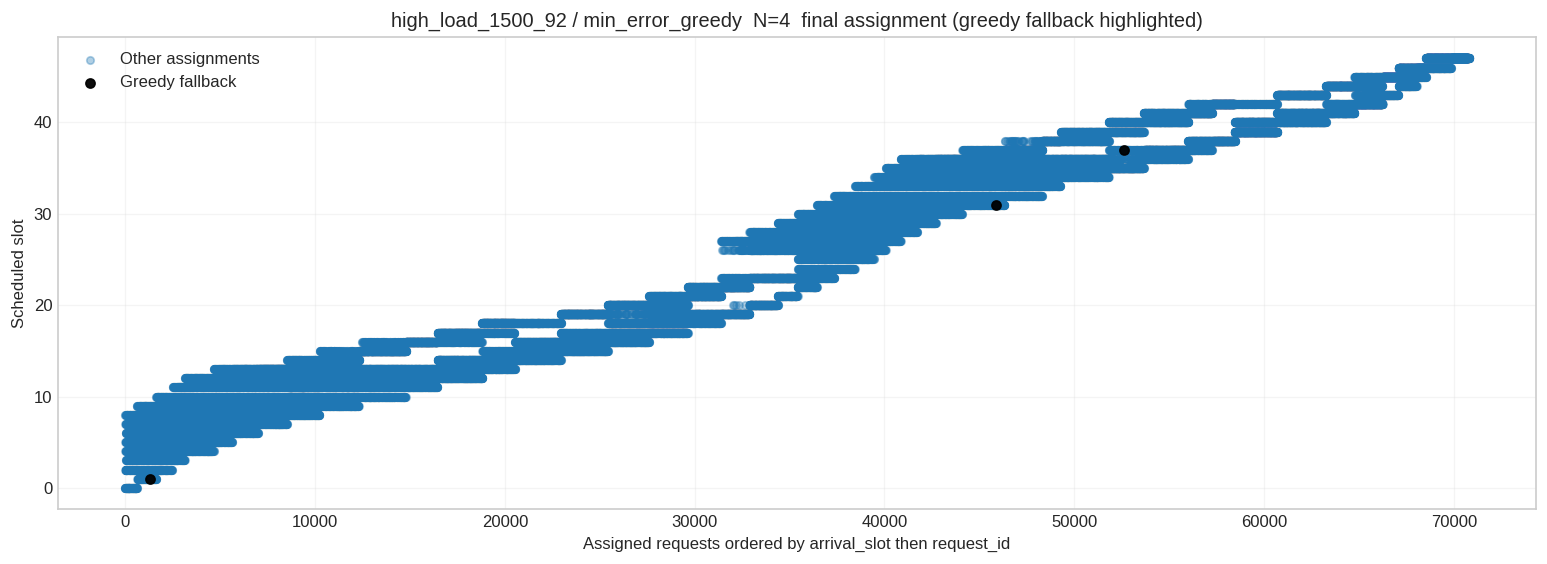

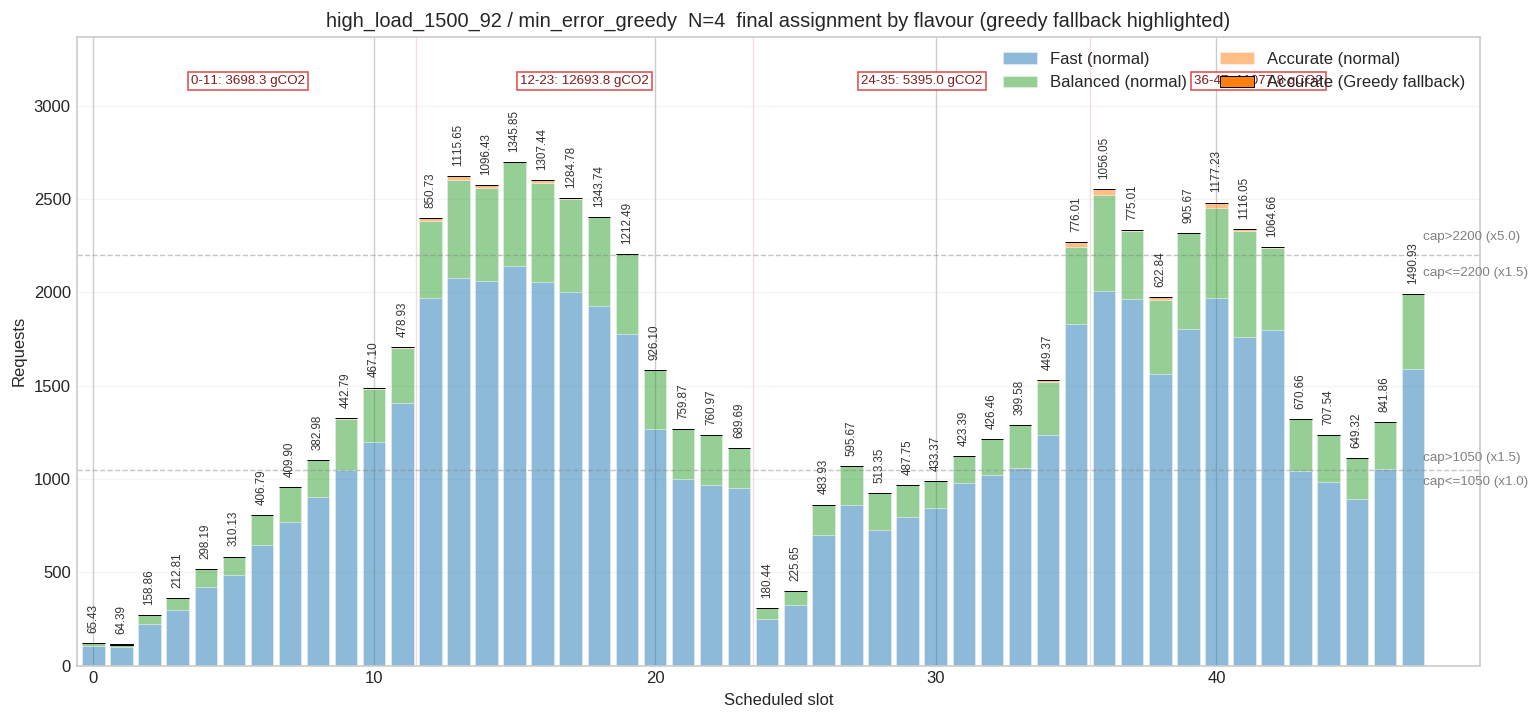

In [17]:
# --- final assignment only: no per-run animation, just the end state ---
# A run only ever highlights ONE of greedy_fallback/relaxed_retry (whichever
# infeasibility mode nshift was run with) — the other flag column is present
# but always empty. Only plot the strategy that actually has assignments,
# instead of always rendering both (one of which would be an empty no-op).
timeline_df = _prepare_timeline(per_request)

_STRATEGY_FLAGS = [
    ("assigned_with_greedy_fallback", "Greedy fallback", "greedy fallback"),
    ("assigned_with_relaxed_retry", "Relaxed retry", "relaxed retry"),
]

_present_flags = [
    (flag_col, dark_label, tag)
    for flag_col, dark_label, tag in _STRATEGY_FLAGS
    if flag_col in timeline_df.columns and bool(_bool_series(timeline_df[flag_col]).any())
]

if not _present_flags:
    print(
        "No greedy_fallback or relaxed_retry assignments found in this run; "
        "skipping final assignment plots."
    )
else:
    if len(_present_flags) == 1:
        print(f"Only {_present_flags[0][1]} assignments found in this run; showing that plot only.")
    for flag_col, dark_label, tag in _present_flags:
        _plot_timeline(
            timeline_df,
            flag_col=flag_col,
            title_scatter=f"{scenario_id} / {mode_label}  N={SELECTED_N}  final assignment ({tag} highlighted)",
            title_stacked=f"{scenario_id} / {mode_label}  N={SELECTED_N}  final assignment by flavour ({tag} highlighted)",
            dark_label=dark_label,
        )